# Etapa 5 - Análisis de relaciones

Ejecutar todas las celdas en orden desde el repositorio o notebooks/. Requiere pandas, openpyxl, numpy, scipy, matplotlib e IPython. Solo lee el Excel procesado. Genera reports/05_relaciones.md y siete PNG en outputs/figuras/relaciones/. No modifica datos ni entregables anteriores.

In [1]:
from pathlib import Path
import hashlib, re, platform
import pandas as pd
import numpy as np
import scipy
from scipy import stats
from scipy.stats.contingency import association
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"data/processed/dataset_salud_publica_limpio.xlsx").exists())
source=root/"data/processed/dataset_salud_publica_limpio.xlsx"
protected=[source,root/"dataset_salud_publica_2500.xlsx"]+[p for folder in ["reports","notebooks"] for p in (root/folder).glob("0[1234]*") if p.is_file()]+list((root/"outputs/figuras/eda").glob("*.png"))
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
prior={p.name:p.read_text(encoding="utf-8") for p in (root/"reports").glob("0[1234]*.md")}
df=pd.read_excel(source,sheet_name="Salud Publica",engine="openpyxl")
snapshot=df.copy(deep=True)
assert df.shape==(2500,10) and df.ID_Paciente.nunique()==2500 and df.ID_Paciente.notna().all()
out=root/"outputs/figuras/relaciones"
out.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":12,"axes.titlesize":16,"axes.spines.top":False,"axes.spines.right":False,"savefig.dpi":180})
conditions=["Saludable","Aguda","Crónica"]
coverages=["Privada","Pública","Sin cobertura"]
parts,figures,summary,findings=[],[],[],[]
def emit(s):
    parts.append(s)
    display(Markdown(s))
def fmt(v):
    return f"{v:.3f}" if isinstance(v,(float,np.floating)) else str(v)
def table(headers,rows,numeric=()):
    rows=[[fmt(v) for v in r] for r in rows]
    widths=[max(3,len(h),*(len(r[j]) for r in rows)) for j,h in enumerate(headers)]
    lines=["| "+" | ".join(h.ljust(widths[j]) for j,h in enumerate(headers))+" |","| "+" | ".join("-"*(w-1)+":" if j in numeric else "-"*w for j,w in enumerate(widths))+" |"]
    lines+=["| "+" | ".join(v.rjust(widths[j]) if j in numeric else v.ljust(widths[j]) for j,v in enumerate(r))+" |" for r in rows]
    return "\n".join(lines)
def pf(p):
    assert 0<=p<=1
    return "< 0.001" if p<.001 else f"= {p:.4f}"
def complete(columns):
    result=df.loc[df[columns].notna().all(axis=1),columns].copy()
    assert result.notna().all().all()
    return result
def figure(fig,ax,name,why):
    assert ax.has_data()
    fig.tight_layout()
    p=out/name
    fig.savefig(p,bbox_inches="tight",facecolor="white")
    plt.close(fig)
    assert plt.imread(p).std()>.01
    figures.append(p)
    emit(f"**Visualización y justificación:** {why}\n\n![{name}](../outputs/figuras/relaciones/{name})")
    display(Image(filename=str(p)))
def box(data,group,value,order,title,unit,name):
    samples=[data.loc[data[group].eq(k),value].to_numpy() for k in order]
    fig,ax=plt.subplots(figsize=(9.5,5.5))
    ax.boxplot(samples,tick_labels=[f"{k}\nN={len(s)}" for k,s in zip(order,samples)],patch_artist=True,
               boxprops={"facecolor":"#B5D8DF"},medianprops={"color":"#26394A","linewidth":2})
    ax.set(title=f"{title}\nN efectivo = {len(data)}",xlabel=group.replace("_"," "),ylabel=unit)
    figure(fig,ax,name,"Boxplots en orden lógico comparan mediana, intervalo intercuartílico, dispersión y solapamiento. Bigotes de 1.5 × IQR; puntos exteriores, si existen, se conservan y no se consideran errores automáticamente.")
    return samples
def grouped(data,group,value,order,include_total=False):
    rows=[]
    for k in order:
        s=data.loc[data[group].eq(k),value]
        rows.append([k,len(s),s.mean(),s.median(),s.std(ddof=1),s.quantile(.25),s.quantile(.75),s.min(),s.max()])
    emit(table(["Grupo","N","Media","Mediana","DE","Q1","Q3","Mínimo","Máximo"],rows,numeric=tuple(range(1,9))))
    return rows
emit("# Etapa 5 - Análisis de relaciones\n\n## 1. Objetivo y metodología\n\n"
     "Analizar diferencias, evidencia estadística y magnitud de las relaciones planteadas en el caso, exclusivamente en el dataset ficticio procesado. "
     "Se leyeron los informes de las Etapas 1–4. Cada análisis selecciona temporalmente casos completos solo en las variables necesarias e informa N y exclusiones; el dataset y sus NA permanecen intactos.\n\n"
     "**α = 0.05**, contrastes globales o bilaterales según corresponda. Se aplican cinco pruebas principales: dos Kruskal-Wallis, dos chi-cuadrado y un Spearman. "
     "Los p-values son nominales, sin ajuste por multiplicidad: se interpretan como exploratorios, no como confirmación simultánea de todas las hipótesis. "
     "Un p-value pequeño no mide fuerza ni relevancia práctica. No se realizan post-hoc: las preguntas globales no requieren contrastar cada par.\n\n"
     "Una fila representa un paciente y los 2500 IDs son únicos; eso es compatible con observaciones separadas, pero no demuestra independencia estadística. "
     "La independencia se adopta como supuesto de trabajo del ejercicio; no se documentan muestreo ni posibles agrupamientos. "
     "Los contrastes describen compatibilidad con hipótesis bajo ese supuesto y no permiten generalizar a población real.\n\n"
     "Desviaciones estándar muestrales (ddof=1), cuartiles con interpolación lineal. Satisfacción se conserva ordinal, con rangos medios para empates en Spearman. "
     "Se usa p < 0.001 para valores extremadamente pequeños, incluso si el cálculo en coma flotante devuelve cero por subdesbordamiento; no significa probabilidad matemáticamente nula.\n\n"
     f"Entorno: Python {platform.python_version()}, pandas {pd.__version__}, scipy {scipy.__version__}, matplotlib {matplotlib.__version__}.")


# Etapa 5 - Análisis de relaciones

## 1. Objetivo y metodología

Analizar diferencias, evidencia estadística y magnitud de las relaciones planteadas en el caso, exclusivamente en el dataset ficticio procesado. Se leyeron los informes de las Etapas 1–4. Cada análisis selecciona temporalmente casos completos solo en las variables necesarias e informa N y exclusiones; el dataset y sus NA permanecen intactos.

**α = 0.05**, contrastes globales o bilaterales según corresponda. Se aplican cinco pruebas principales: dos Kruskal-Wallis, dos chi-cuadrado y un Spearman. Los p-values son nominales, sin ajuste por multiplicidad: se interpretan como exploratorios, no como confirmación simultánea de todas las hipótesis. Un p-value pequeño no mide fuerza ni relevancia práctica. No se realizan post-hoc: las preguntas globales no requieren contrastar cada par.

Una fila representa un paciente y los 2500 IDs son únicos; eso es compatible con observaciones separadas, pero no demuestra independencia estadística. La independencia se adopta como supuesto de trabajo del ejercicio; no se documentan muestreo ni posibles agrupamientos. Los contrastes describen compatibilidad con hipótesis bajo ese supuesto y no permiten generalizar a población real.

Desviaciones estándar muestrales (ddof=1), cuartiles con interpolación lineal. Satisfacción se conserva ordinal, con rangos medios para empates en Spearman. Se usa p < 0.001 para valores extremadamente pequeños, incluso si el cálculo en coma flotante devuelve cero por subdesbordamiento; no significa probabilidad matemáticamente nula.

Entorno: Python 3.12.3, pandas 3.0.5, scipy 1.18.1, matplotlib 3.11.2.

## 2. Condición de salud y frecuencia de atención

N efectivo: **2500**; excluidos por NA: **0**.

| Grupo     | N   | Media  | Mediana | DE    | Q1    | Q3     | Mínimo | Máximo |
| --------- | --: | -----: | ------: | ----: | ----: | -----: | -----: | -----: |
| Saludable | 828 |  1.488 |   1.000 | 1.116 | 1.000 |  3.000 |      0 |      3 |
| Aguda     | 829 |  4.031 |   4.000 | 1.385 | 3.000 |  5.000 |      2 |      6 |
| Crónica   | 843 | 12.926 |  13.000 | 4.192 | 9.000 | 16.000 |      6 |     20 |

**Visualización y justificación:** Boxplots en orden lógico comparan mediana, intervalo intercuartílico, dispersión y solapamiento. Bigotes de 1.5 × IQR; puntos exteriores, si existen, se conservan y no se consideran errores automáticamente.

![frecuencia_por_condicion.png](../outputs/figuras/relaciones/frecuencia_por_condicion.png)

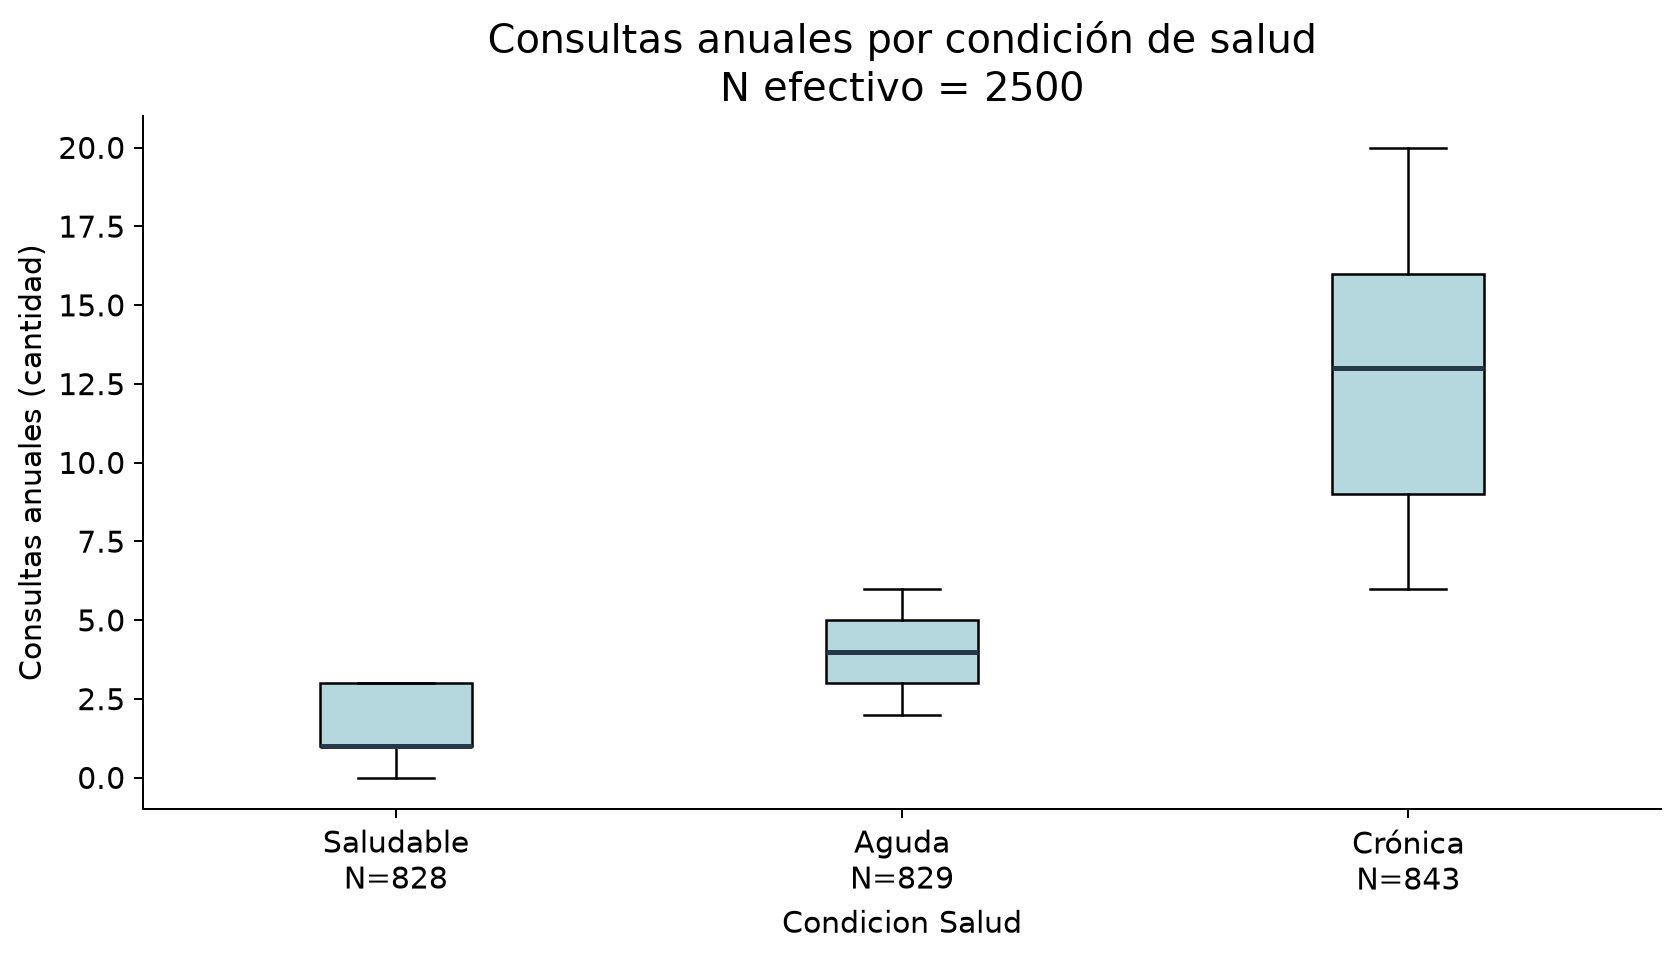

Evaluación previa: el conteo tiene empates y límites observados distintos: Saludable 0–3, Aguda 2–6 y Crónica 6–20. Las DE y los IQR de la tabla muestran dispersiones diferentes; no se presume normalidad ni igualdad de forma. Kruskal-Wallis es adecuado como contraste global de rangos de tres grupos independientes bajo el supuesto indicado; no se interpreta exclusivamente como diferencia de medianas. Cada grupo supera cinco observaciones. [Método y corrección de empates: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html).

**Kruskal-Wallis:** H=2042.640, gl=2, p < 0.001, N=2500. log10(p) de la aproximación χ²₂ = -443.55. Se rechaza la hipótesis global de distribuciones iguales a α=0.05. Hay evidencia de diferencias en rangos entre grupos; no se identifica inferencialmente cada par. La magnitud descriptiva se aprecia en medianas 1, 4 y 13 consultas y en sus IQR; el p-value no cuantifica esa separación.

## 3. Cobertura y tiempo de espera

| Cobertura     | N total | N disponible | NA  | Media min | Mediana min | DE min | Q1 min | Q3 min  |
| ------------- | ------: | -----------: | --: | --------: | ----------: | -----: | -----: | ------: |
| Privada       |     843 |          823 |  20 |    17.601 |      18.000 |  7.502 | 11.000 |  24.000 |
| Pública       |     806 |          777 |  29 |    70.192 |      71.000 | 29.254 | 45.000 |  95.000 |
| Sin cobertura |     851 |          826 |  25 |   106.111 |     105.000 | 43.260 | 70.000 | 144.000 |

N efectivo total: **2426**; excluidos por NA: **74**.

**Visualización y justificación:** Boxplots en orden lógico comparan mediana, intervalo intercuartílico, dispersión y solapamiento. Bigotes de 1.5 × IQR; puntos exteriores, si existen, se conservan y no se consideran errores automáticamente.

![espera_por_cobertura_boxplot.png](../outputs/figuras/relaciones/espera_por_cobertura_boxplot.png)

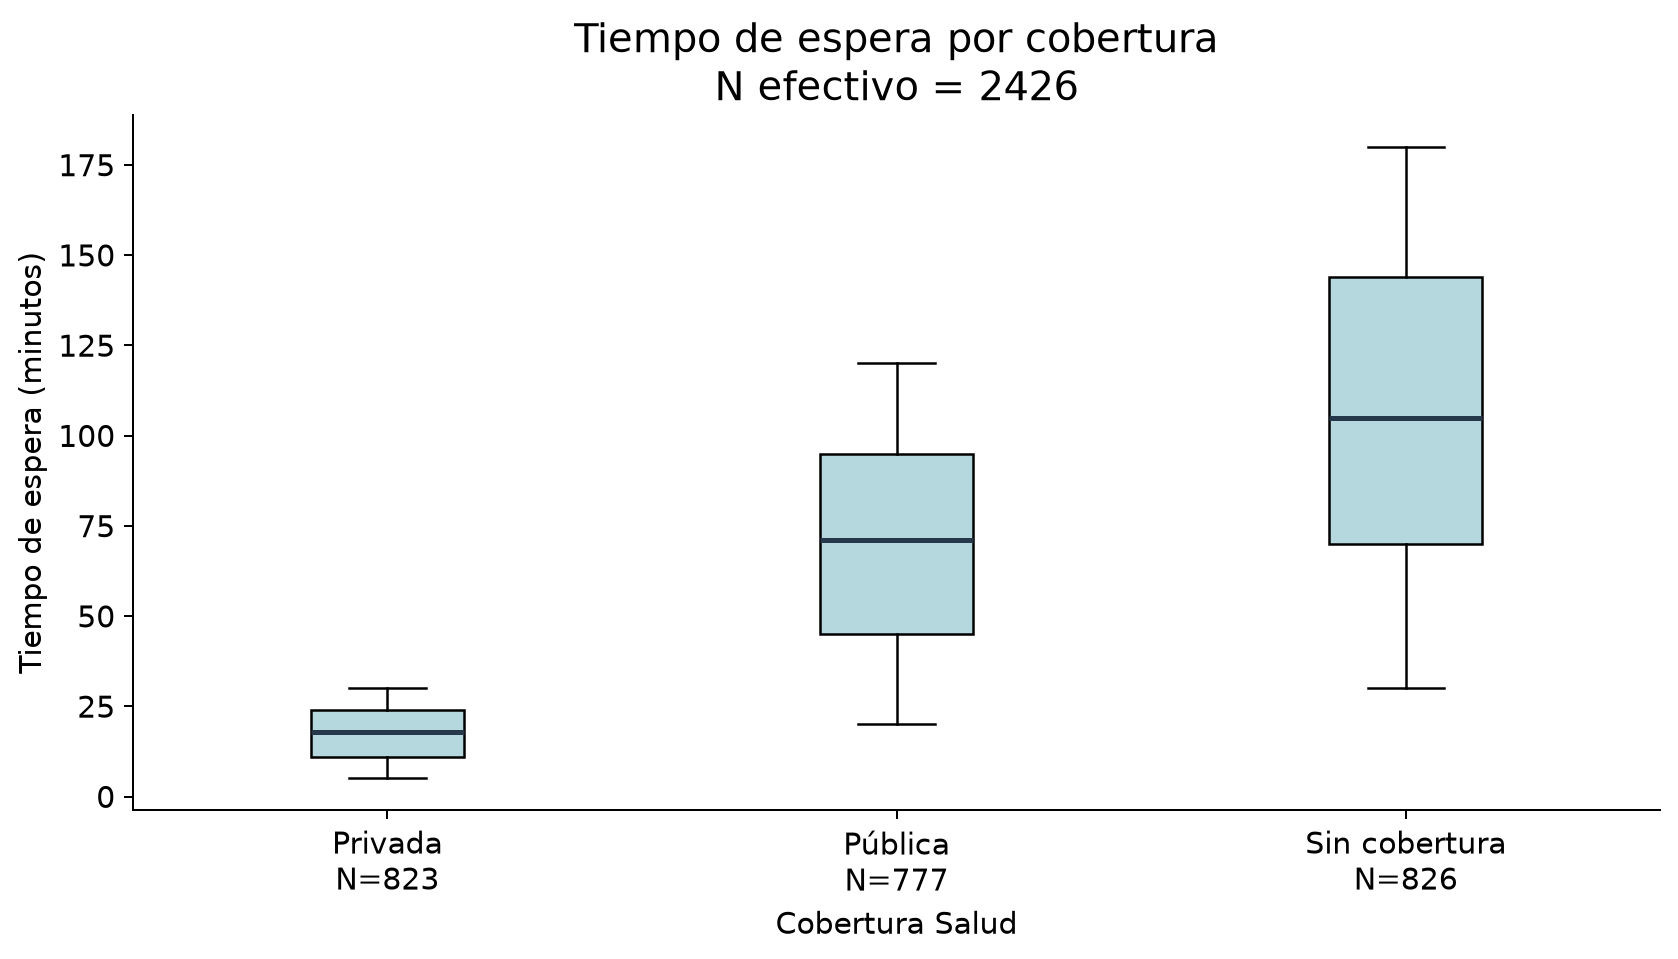

Evaluación previa: los rangos observados son 5–30, 20–120 y 30–180 minutos; los IQR son 13, 50 y 74 minutos. Hay dispersiones distintas y duraciones acotadas con empates; no se supone normalidad. Se aplica Kruskal-Wallis como contraste global de rangos, con cientos de casos por grupo, sin atribuir todo el resultado a diferencias de medianas.

**Kruskal-Wallis:** H=1684.378, gl=2, p < 0.001, N=2426; log10(p) aproximado χ²₂=-365.76. Se rechaza la hipótesis global a α=0.05. Medianas 18, 71 y 105 min para Privada, Pública y Sin cobertura: diferencias observadas de ubicación y dispersión. No se concluye que la cobertura cause la espera ni que cada par sea significativo.

In [2]:
emit("## 2. Condición de salud y frecuencia de atención")
a=complete(["Condicion_Salud","Frecuencia_Atencion"])
emit(f"N efectivo: **{len(a)}**; excluidos por NA: **{len(df)-len(a)}**.")
ra=grouped(a,"Condicion_Salud","Frecuencia_Atencion",conditions)
sa=box(a,"Condicion_Salud","Frecuencia_Atencion",conditions,"Consultas anuales por condición de salud","Consultas anuales (cantidad)","frecuencia_por_condicion.png")
emit("Evaluación previa: el conteo tiene empates y límites observados distintos: Saludable 0–3, Aguda 2–6 y Crónica 6–20. "
     "Las DE y los IQR de la tabla muestran dispersiones diferentes; no se presume normalidad ni igualdad de forma. "
     "Kruskal-Wallis es adecuado como contraste global de rangos de tres grupos independientes bajo el supuesto indicado; no se interpreta exclusivamente como diferencia de medianas. "
     "Cada grupo supera cinco observaciones. [Método y corrección de empates: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html).")
ka=stats.kruskal(*sa,nan_policy="raise")
assert min(map(len,sa))>=5
# Con tres grupos, la cola chi-cuadrado de 2 gl es exp(-H/2).
assert np.isclose(ka.pvalue,np.exp(-ka.statistic/2),rtol=1e-10,atol=0)
emit(f"**Kruskal-Wallis:** H={ka.statistic:.3f}, gl=2, p {pf(ka.pvalue)}, N={len(a)}. "
     f"log10(p) de la aproximación χ²₂ = {-ka.statistic/(2*np.log(10)):.2f}. "
     "Se rechaza la hipótesis global de distribuciones iguales a α=0.05. Hay evidencia de diferencias en rangos entre grupos; no se identifica inferencialmente cada par. "
     "La magnitud descriptiva se aprecia en medianas 1, 4 y 13 consultas y en sus IQR; el p-value no cuantifica esa separación.")
summary.append(["Condición–frecuencia",len(a),"Kruskal-Wallis",f"H={ka.statistic:.3f}",pf(ka.pvalue),"No aplicada (estandarizada); medianas 1 / 4 / 13","Diferencias globales de rangos; dispersión desigual."])
findings.append((f"Medianas 1, 4 y 13 consultas para Saludable, Aguda y Crónica; H={ka.statistic:.3f}, p {pf(ka.pvalue)}, N={len(a)}.",
                 "Se observan diferencias globales de rangos y separación descriptiva de las distribuciones.",
                 "Sin post-hoc no se afirma significación de cada par; no es un efecto causal ni una prueba exclusiva de medianas."))
emit("## 3. Cobertura y tiempo de espera")
b=complete(["Cobertura_Salud","Tiempo_Espera_min"])
rb=[]
for k in coverages:
    s=b.loc[b.Cobertura_Salud.eq(k),"Tiempo_Espera_min"]
    total=int(df.Cobertura_Salud.eq(k).sum())
    rb.append([k,total,len(s),total-len(s),s.mean(),s.median(),s.std(ddof=1),s.quantile(.25),s.quantile(.75)])
emit(table(["Cobertura","N total","N disponible","NA","Media min","Mediana min","DE min","Q1 min","Q3 min"],rb,numeric=tuple(range(1,9))))
emit(f"N efectivo total: **{len(b)}**; excluidos por NA: **{len(df)-len(b)}**.")
sb=box(b,"Cobertura_Salud","Tiempo_Espera_min",coverages,"Tiempo de espera por cobertura","Tiempo de espera (minutos)","espera_por_cobertura_boxplot.png")
emit("Evaluación previa: los rangos observados son 5–30, 20–120 y 30–180 minutos; los IQR son 13, 50 y 74 minutos. "
     "Hay dispersiones distintas y duraciones acotadas con empates; no se supone normalidad. Se aplica Kruskal-Wallis como contraste global de rangos, "
     "con cientos de casos por grupo, sin atribuir todo el resultado a diferencias de medianas.")
kb=stats.kruskal(*sb,nan_policy="raise")
assert np.isclose(kb.pvalue,np.exp(-kb.statistic/2),rtol=1e-10,atol=0)
emit(f"**Kruskal-Wallis:** H={kb.statistic:.3f}, gl=2, p {pf(kb.pvalue)}, N={len(b)}; "
     f"log10(p) aproximado χ²₂={-kb.statistic/(2*np.log(10)):.2f}. "
     "Se rechaza la hipótesis global a α=0.05. Medianas 18, 71 y 105 min para Privada, Pública y Sin cobertura: diferencias observadas de ubicación y dispersión. "
     "No se concluye que la cobertura cause la espera ni que cada par sea significativo.")
summary.append(["Cobertura–espera",len(b),"Kruskal-Wallis",f"H={kb.statistic:.3f}",pf(kb.pvalue),"No aplicada (estandarizada); medianas 18 / 71 / 105 min","Diferencias globales; no solo medias."])
findings.append((f"Medianas 18, 71 y 105 min; H={kb.statistic:.3f}, p {pf(kb.pvalue)}, N={len(b)}, 74 NA excluidos.",
                 "Las distribuciones de espera difieren entre coberturas en ubicación y dispersión.",
                 "El contraste global no prueba causalidad; las formas distintas impiden interpretarlo solo como prueba de medianas."))


## 4. Cobertura y acceso a medicación

N efectivo: **2500**; excluidos por NA: **0**. Porcentajes dentro de cada grupo.

| Cobertura_Salud | Sí (n) | No (n) | N   | Sí (%) | No (%) |
| --------------- | -----: | -----: | --: | -----: | -----: |
| Privada         |    717 |    126 | 843 | 85.053 | 14.947 |
| Pública         |    562 |    244 | 806 | 69.727 | 30.273 |
| Sin cobertura   |    416 |    435 | 851 | 48.884 | 51.116 |

**Visualización y justificación:** Barras apiladas al 100% comparan la composición Sí/No dentro de cada grupo, independientemente de su tamaño; etiquetas y N explicitan el denominador.

![acceso_por_cobertura.png](../outputs/figuras/relaciones/acceso_por_cobertura.png)

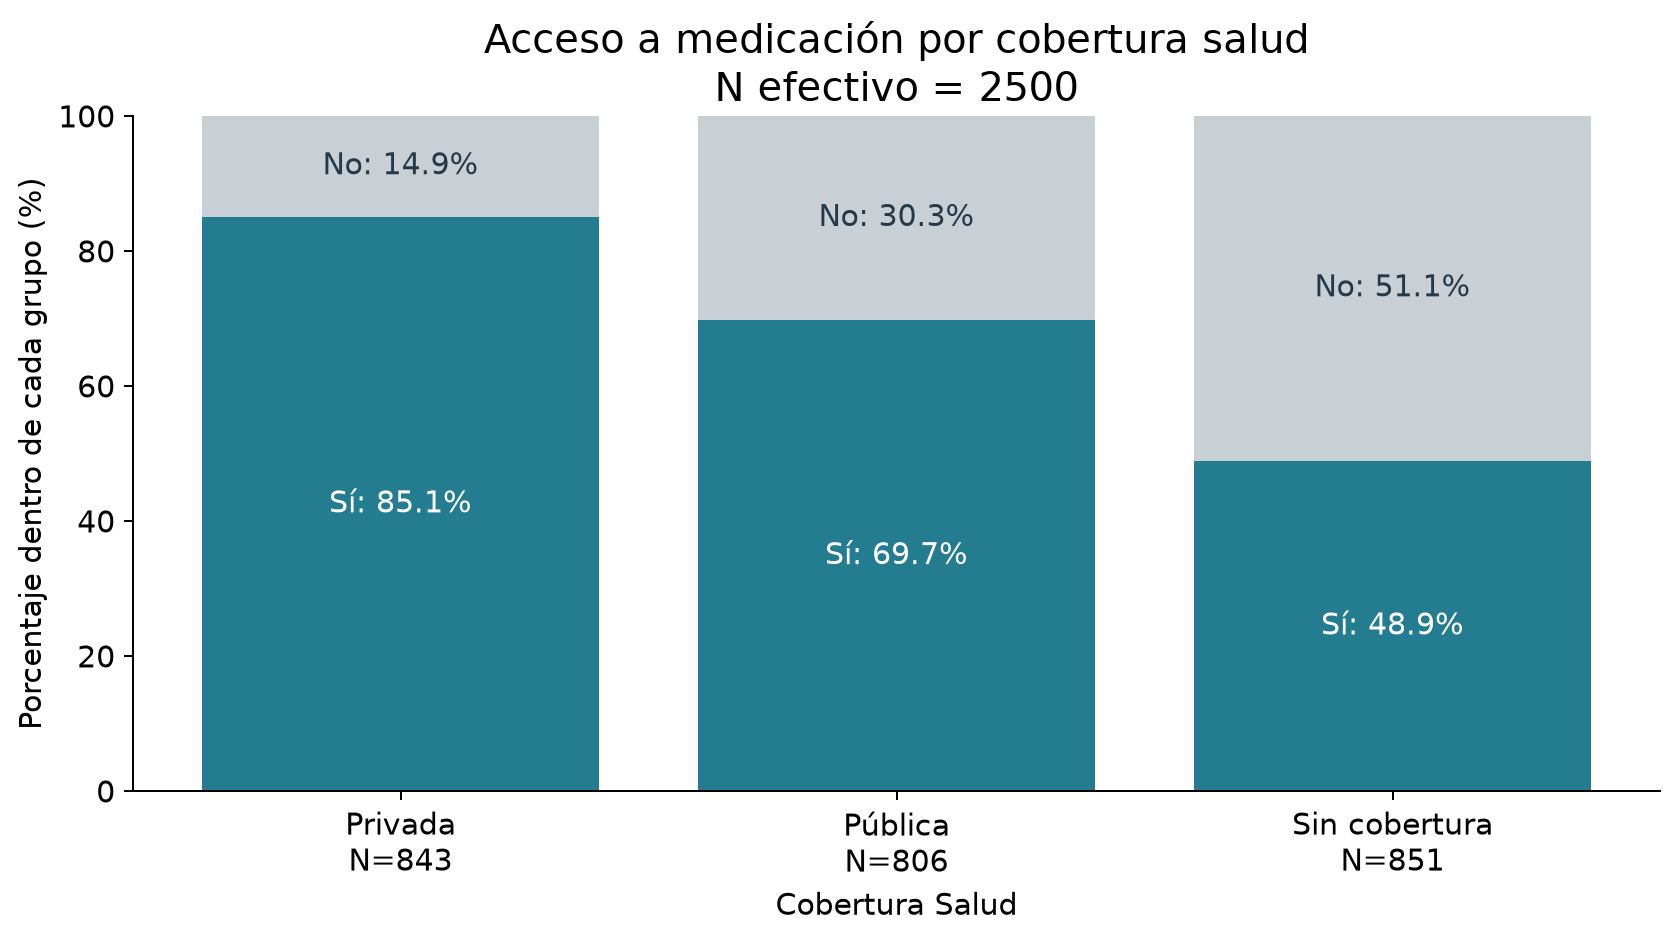

Frecuencias esperadas bajo independencia:

| Cobertura_Salud | Sí esperado | No esperado |
| --------------- | ----------: | ----------: |
| Privada         |     571.554 |     271.446 |
| Pública         |     546.468 |     259.532 |
| Sin cobertura   |     576.978 |     274.022 |

**Chi-cuadrado:** χ²=255.798, gl=2, p < 0.001, N=2500. **V de Cramér=0.3199**. Mínimo esperado=259.532; celdas esperadas <5: 0; mínimo observado=126. Se usan conteos, categorías excluyentes y una celda por paciente. Se cumple el control de frecuencias; la independencia entre pacientes sigue siendo un supuesto de trabajo. Se aplica χ² de independencia sin corrección de continuidad (tabla 3×2, gl=2). [Supuestos y cálculo: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).

**Significación:** hay evidencia de asociación al nivel nominal 0.05. **Magnitud:** V=0.3199 en escala 0–1, sin dirección ni interpretación de porcentaje de varianza. Se interpreta junto con las proporciones observadas, sin umbrales universales de importancia. Fórmula sin corrección por sesgo: V = √[χ² / (N × min(r−1,c−1))]; aquí min(r−1,c−1)=1. [Verificación de V: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html).

## 5. Condición de salud y acceso a medicación

N efectivo: **2500**; excluidos por NA: **0**. Porcentajes dentro de cada grupo.

| Condicion_Salud | Sí (n) | No (n) | N   | Sí (%) | No (%) |
| --------------- | -----: | -----: | --: | -----: | -----: |
| Saludable       |    589 |    239 | 828 | 71.135 | 28.865 |
| Aguda           |    592 |    237 | 829 | 71.411 | 28.589 |
| Crónica         |    514 |    329 | 843 | 60.973 | 39.027 |

**Visualización y justificación:** Barras apiladas al 100% comparan la composición Sí/No dentro de cada grupo, independientemente de su tamaño; etiquetas y N explicitan el denominador.

![acceso_por_condicion.png](../outputs/figuras/relaciones/acceso_por_condicion.png)

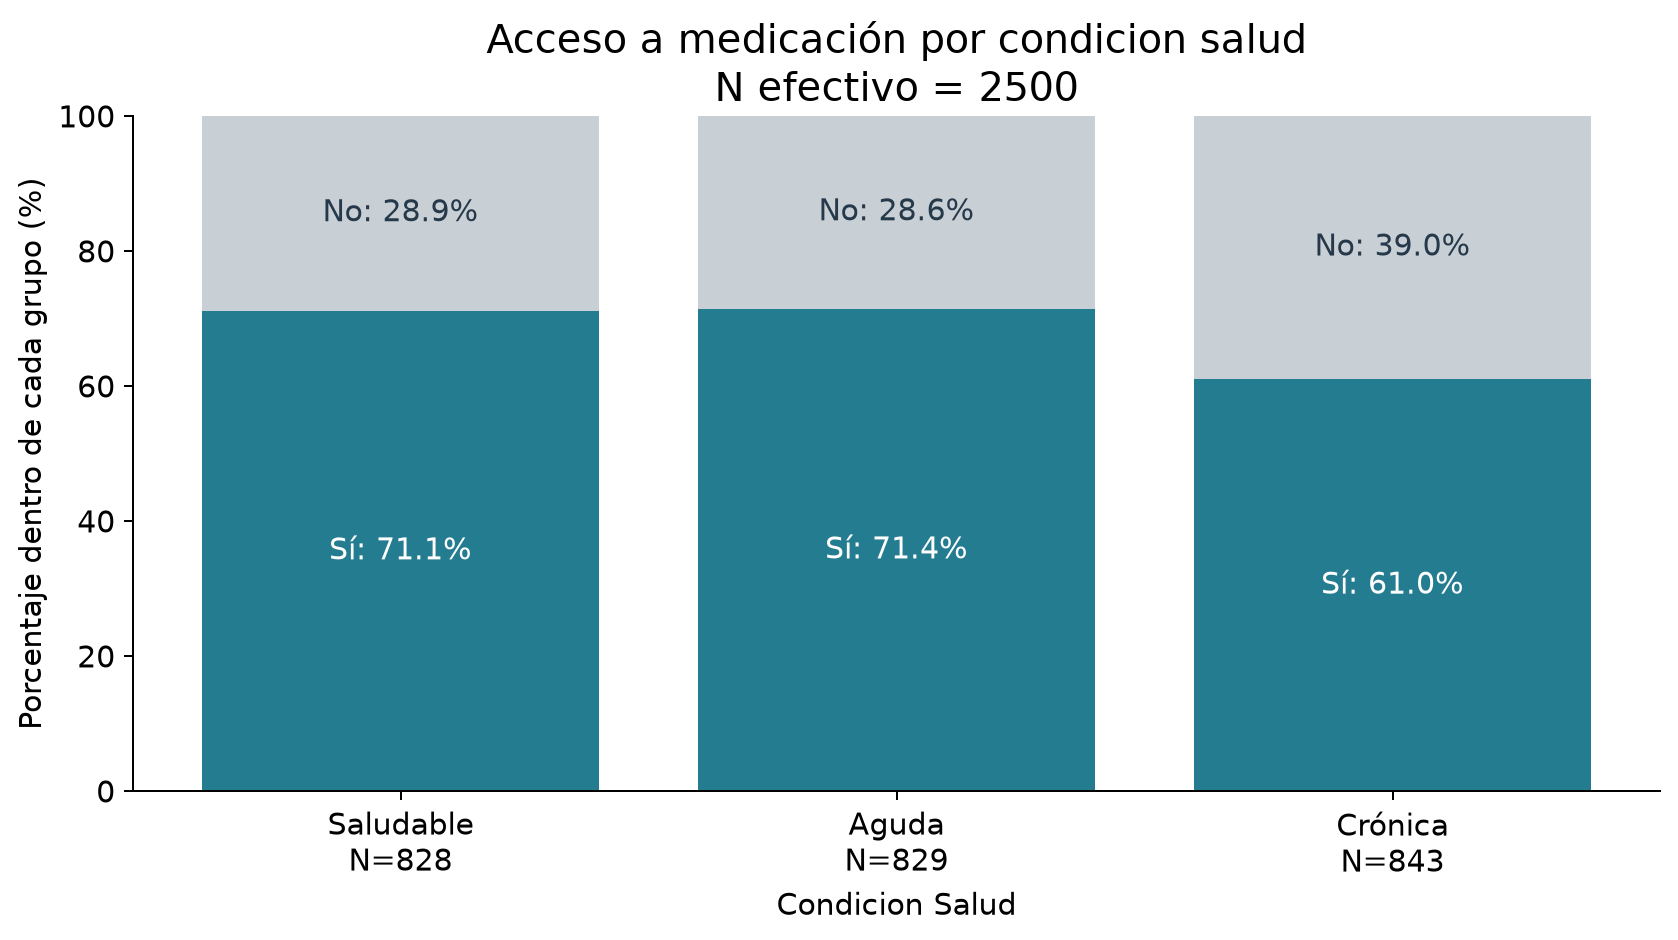

Frecuencias esperadas bajo independencia:

| Condicion_Salud | Sí esperado | No esperado |
| --------------- | ----------: | ----------: |
| Saludable       |     561.384 |     266.616 |
| Aguda           |     562.062 |     266.938 |
| Crónica         |     571.554 |     271.446 |

**Chi-cuadrado:** χ²=27.170, gl=2, p < 0.001, N=2500. **V de Cramér=0.1042**. Mínimo esperado=266.616; celdas esperadas <5: 0; mínimo observado=237. Se usan conteos, categorías excluyentes y una celda por paciente. Se cumple el control de frecuencias; la independencia entre pacientes sigue siendo un supuesto de trabajo. Se aplica χ² de independencia sin corrección de continuidad (tabla 3×2, gl=2). [Supuestos y cálculo: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).

**Significación:** hay evidencia de asociación al nivel nominal 0.05. **Magnitud:** V=0.1042 en escala 0–1, sin dirección ni interpretación de porcentaje de varianza. Se interpreta junto con las proporciones observadas, sin umbrales universales de importancia. Fórmula sin corrección por sesgo: V = √[χ² / (N × min(r−1,c−1))]; aquí min(r−1,c−1)=1. [Verificación de V: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html).

Comparación de magnitudes en tablas del mismo tamaño: V cobertura=0.3199 frente a V condición=0.1042. La asociación marginal de cobertura con acceso es mayor en este dataset, aunque ambas pruebas pueden arrojar p-values pequeños. Esto no compara efectos independientes ni importancia clínica.

In [3]:
def access_analysis(group,order,title,name):
    d=complete([group,"Acceso_Medicacion"])
    ct=pd.crosstab(d[group],d.Acceso_Medicacion).reindex(index=order,columns=["Sí","No"],fill_value=0)
    ns=ct.sum(axis=1)
    pc=ct.div(ns,axis=0)*100
    assert int(ct.to_numpy().sum())==len(d) and np.allclose(pc.sum(axis=1),100)
    emit(title+f"\n\nN efectivo: **{len(d)}**; excluidos por NA: **{len(df)-len(d)}**. Porcentajes dentro de cada grupo.")
    emit(table([group,"Sí (n)","No (n)","N","Sí (%)","No (%)"],
               [[k,int(ct.loc[k,"Sí"]),int(ct.loc[k,"No"]),int(ns[k]),pc.loc[k,"Sí"],pc.loc[k,"No"]] for k in order],numeric=(1,2,3,4,5)))
    fig,ax=plt.subplots(figsize=(9.5,5.4))
    ax.bar(order,pc["Sí"],color="#247C91",label="Sí")
    ax.bar(order,pc["No"],bottom=pc["Sí"],color="#C8CFD5",label="No")
    for i,k in enumerate(order):
        for category,base in [("Sí",0),("No",pc.loc[k,"Sí"])]:
            value=pc.loc[k,category]
            ax.text(i,base+value/2,f"{category}: {value:.1f}%",ha="center",va="center",color="white" if category=="Sí" else "#26394A")
    ax.set(title=f"Acceso a medicación por {group.replace('_',' ').lower()}\nN efectivo = {len(d)}",ylabel="Porcentaje dentro de cada grupo (%)",xlabel=group.replace("_"," "),ylim=(0,100))
    ax.set_xticks(range(len(order)),[f"{k}\nN={ns[k]}" for k in order])
    figure(fig,ax,name,"Barras apiladas al 100% comparan la composición Sí/No dentro de cada grupo, independientemente de su tamaño; etiquetas y N explicitan el denominador.")
    chi,p,dof,expected=stats.chi2_contingency(ct.to_numpy(),correction=False)
    manual_expected=np.outer(ct.sum(axis=1),ct.sum(axis=0))/len(d)
    assert np.allclose(expected,manual_expected)
    assert np.isclose(chi,((ct.to_numpy()-expected)**2/expected).sum())
    assert np.isclose(p,stats.chi2.sf(chi,dof))
    v=np.sqrt(chi/(len(d)*min(ct.shape[0]-1,ct.shape[1]-1)))
    assert np.isclose(v,association(ct.to_numpy(),method="cramer",correction=False))
    assert expected.min()>=5 and ct.to_numpy().min()>=5
    emit("Frecuencias esperadas bajo independencia:\n\n"+table([group,"Sí esperado","No esperado"],[[k,*expected[i]] for i,k in enumerate(order)],numeric=(1,2)))
    emit(f"**Chi-cuadrado:** χ²={chi:.3f}, gl={dof}, p {pf(p)}, N={len(d)}. **V de Cramér={v:.4f}**. "
         f"Mínimo esperado={expected.min():.3f}; celdas esperadas <5: {int((expected<5).sum())}; mínimo observado={ct.to_numpy().min()}. "
         "Se usan conteos, categorías excluyentes y una celda por paciente. Se cumple el control de frecuencias; la independencia entre pacientes sigue siendo un supuesto de trabajo. "
         "Se aplica χ² de independencia sin corrección de continuidad (tabla 3×2, gl=2). "
         "[Supuestos y cálculo: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).\n\n"
         "**Significación:** "+("hay evidencia de asociación" if p<.05 else "no se encuentra evidencia suficiente de asociación")+f" al nivel nominal 0.05. "
         f"**Magnitud:** V={v:.4f} en escala 0–1, sin dirección ni interpretación de porcentaje de varianza. "
         "Se interpreta junto con las proporciones observadas, sin umbrales universales de importancia. "
         "Fórmula sin corrección por sesgo: V = √[χ² / (N × min(r−1,c−1))]; aquí min(r−1,c−1)=1. "
         "[Verificación de V: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html).")
    return {"ct":ct,"pc":pc,"n":len(d),"chi":chi,"p":p,"v":v,"expected":expected}
c=access_analysis("Cobertura_Salud",coverages,"## 4. Cobertura y acceso a medicación","acceso_por_cobertura.png")
e=access_analysis("Condicion_Salud",conditions,"## 5. Condición de salud y acceso a medicación","acceso_por_condicion.png")
for relation,result in [("Cobertura–medicación",c),("Condición–medicación",e)]:
    p=result["pc"]["Sí"]
    summary.append([relation,result["n"],"Chi-cuadrado",f"χ²={result['chi']:.3f}; gl=2",pf(result["p"]),f"V={result['v']:.4f}","Asociación nominal; magnitud separada del p-value."])
    findings.append((f"{relation}: χ²={result['chi']:.3f}, gl=2, p {pf(result['p'])}, V={result['v']:.4f}, N={result['n']}; acceso Sí entre {p.min():.2f}% y {p.max():.2f}%.",
                     "Se observa asociación; su magnitud se expresa con V y las diferencias de proporciones.",
                     "Es una asociación marginal, sin ajuste por la otra variable ni interpretación causal."))
emit(f"Comparación de magnitudes en tablas del mismo tamaño: V cobertura={c['v']:.4f} frente a V condición={e['v']:.4f}. "
     "La asociación marginal de cobertura con acceso es mayor en este dataset, aunque ambas pruebas pueden arrojar p-values pequeños. "
     "Esto no compara efectos independientes ni importancia clínica.")


## 6. Cobertura + condición y acceso a medicación

N efectivo: **2500**; excluidos por NA: **0**. Se describen las nueve combinaciones, sin pruebas separadas.

| Cobertura     | Condición | N   | Acceso Sí (n) | Acceso Sí (%) |
| ------------- | --------- | --: | ------------: | ------------: |
| Privada       | Saludable | 272 |           242 |        88.971 |
| Privada       | Aguda     | 269 |           240 |        89.219 |
| Privada       | Crónica   | 302 |           235 |        77.815 |
| Pública       | Saludable | 266 |           193 |        72.556 |
| Pública       | Aguda     | 280 |           208 |        74.286 |
| Pública       | Crónica   | 260 |           161 |        61.923 |
| Sin cobertura | Saludable | 290 |           154 |        53.103 |
| Sin cobertura | Aguda     | 280 |           144 |        51.429 |
| Sin cobertura | Crónica   | 281 |           118 |        41.993 |

**Visualización y justificación:** Un único heatmap 3×3 permite comparar las nueve proporciones simultáneamente; escala fija 0–100%, porcentajes y N en cada celda evitan depender solo del color.

![acceso_cobertura_condicion.png](../outputs/figuras/relaciones/acceso_cobertura_condicion.png)

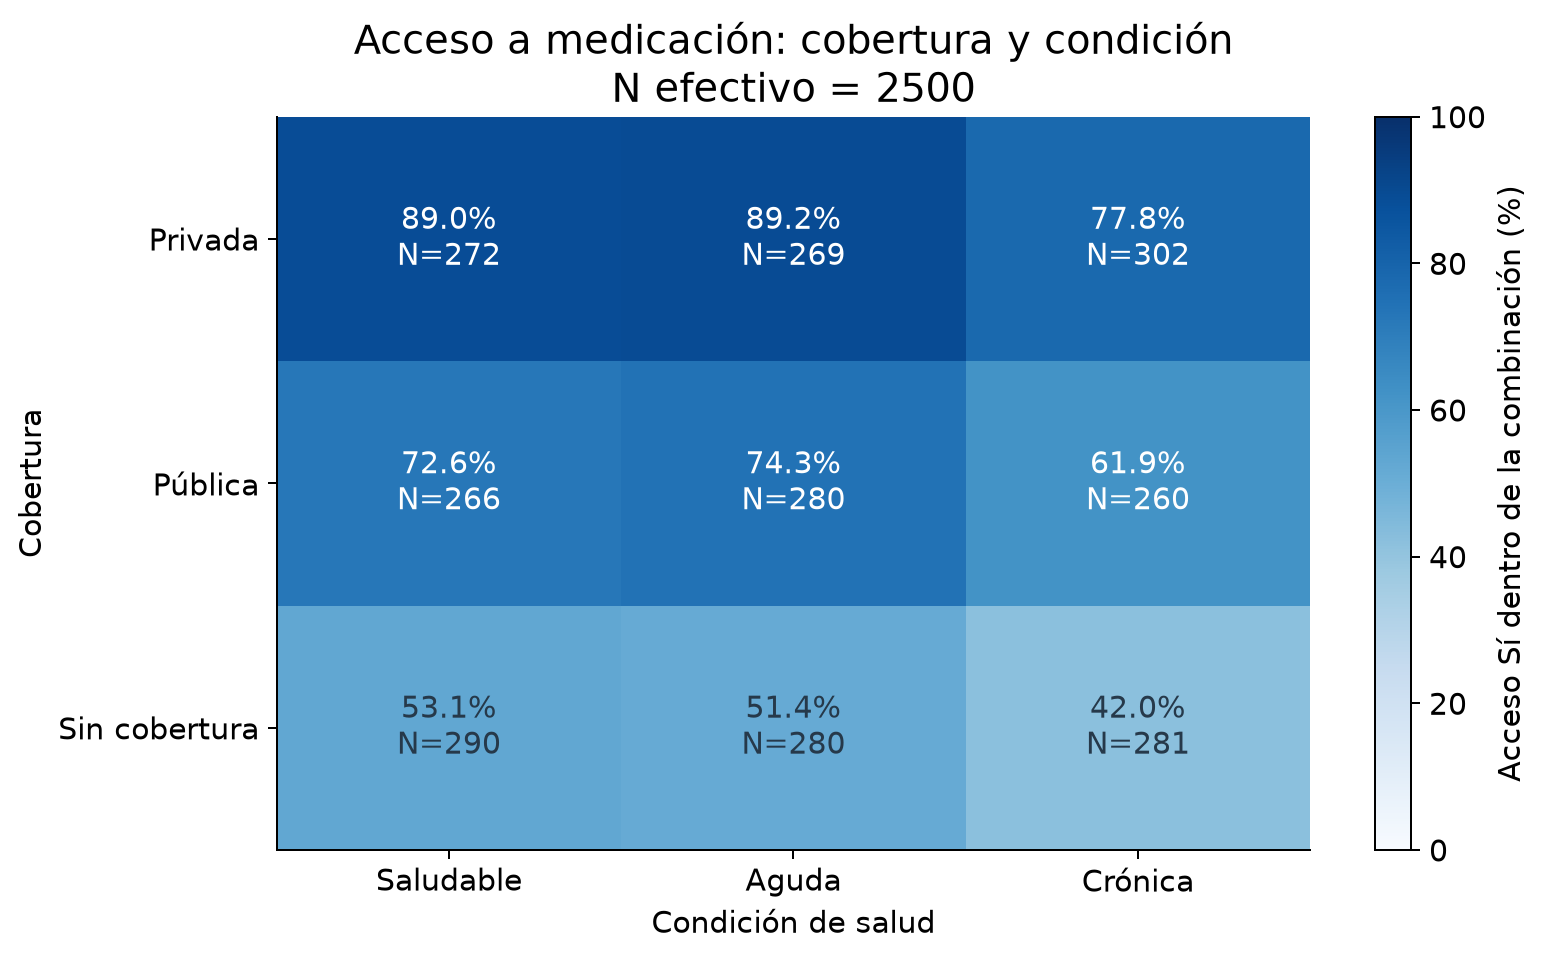

Mayor acceso observado: Privada / Aguda, 240/269 (89.22%); menor: Sin cobertura / Crónica, 118/281 (41.99%). No se asignan etiquetas de vulnerabilidad ni se evalúa una interacción estadística.

In [4]:
emit("## 6. Cobertura + condición y acceso a medicación")
joint=complete(["Cobertura_Salud","Condicion_Salud","Acceso_Medicacion"])
joint_rows=[]
percent_matrix=np.zeros((3,3))
n_matrix=np.zeros((3,3),dtype=int)
for i,cov in enumerate(coverages):
    for j,con in enumerate(conditions):
        s=joint.loc[joint.Cobertura_Salud.eq(cov)&joint.Condicion_Salud.eq(con),"Acceso_Medicacion"]
        yes=int(s.eq("Sí").sum())
        assert len(s)>0
        pct=yes/len(s)*100
        joint_rows.append([cov,con,len(s),yes,pct])
        percent_matrix[i,j]=pct
        n_matrix[i,j]=len(s)
assert n_matrix.sum()==len(joint)
emit(f"N efectivo: **{len(joint)}**; excluidos por NA: **{len(df)-len(joint)}**. Se describen las nueve combinaciones, sin pruebas separadas.\n\n"+
     table(["Cobertura","Condición","N","Acceso Sí (n)","Acceso Sí (%)"],joint_rows,numeric=(2,3,4)))
fig,ax=plt.subplots(figsize=(9,5.5))
im=ax.imshow(percent_matrix,vmin=0,vmax=100,cmap="Blues",aspect="auto")
fig.colorbar(im,ax=ax,label="Acceso Sí dentro de la combinación (%)")
ax.set(xticks=range(3),xticklabels=conditions,yticks=range(3),yticklabels=coverages,xlabel="Condición de salud",ylabel="Cobertura",title=f"Acceso a medicación: cobertura y condición\nN efectivo = {len(joint)}")
for i in range(3):
    for j in range(3):
        ax.text(j,i,f"{percent_matrix[i,j]:.1f}%\nN={n_matrix[i,j]}",ha="center",va="center",color="white" if percent_matrix[i,j]>60 else "#26394A")
figure(fig,ax,"acceso_cobertura_condicion.png","Un único heatmap 3×3 permite comparar las nueve proporciones simultáneamente; escala fija 0–100%, porcentajes y N en cada celda evitan depender solo del color.")
high=max(joint_rows,key=lambda r:r[4]); low=min(joint_rows,key=lambda r:r[4])
joint_result=f"Mayor acceso observado: {high[0]} / {high[1]}, {high[3]}/{high[2]} ({high[4]:.2f}%); menor: {low[0]} / {low[1]}, {low[3]}/{low[2]} ({low[4]:.2f}%)."
emit(joint_result+" No se asignan etiquetas de vulnerabilidad ni se evalúa una interacción estadística.")
summary.append(["Cobertura + condición–medicación",len(joint),"No aplicada (objetivo descriptivo)",joint_result,"No aplicada","No aplicada (sin contraste); porcentajes por combinación","Nueve perfiles; no mide efectos ajustados ni interacción."])
findings.append((joint_result+f" N total={len(joint)}.","Se observan combinaciones con porcentajes relativos distintos.","No se hicieron nueve pruebas; no se concluye interacción, vulnerabilidad ni efecto independiente."))


## 7. Tiempo de espera y satisfacción

N efectivo: **2357**; filas excluidas por NA en cualquiera de las dos variables: **143**. Hay 74 NA en espera y 72 en satisfacción, con 3 coincidentes: 74 + 72 − 3 = 143 exclusiones. No se imputan valores.

**Spearman bilateral:** ρ=-0.7402, p < 0.001, N=2357. Dirección negativa: los rangos de espera mayores tienden a acompañar niveles de satisfacción menores. La magnitud absoluta |ρ|=0.7402 indica una relación monotónica negativa marcada, sin equivaler a porcentaje de varianza explicada. Hay evidencia estadística al nivel nominal 0.05; no implica causalidad ni ajuste por acceso o cobertura. Se usa la aproximación asintótica del p-value con N>500 y rangos medios ante empates; no se utiliza Pearson como análisis principal. [Método e interpretación: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).

| Satisfacción | N   | Media espera min | Mediana min | Q1 min  | Q3 min  |
| -----------: | --: | ---------------: | ----------: | ------: | ------: |
|            1 | 134 |          148.358 |     155.000 | 129.250 | 171.750 |
|            2 | 321 |          117.480 |     115.000 |  92.000 | 149.000 |
|            3 | 561 |           81.474 |      83.000 |  54.000 | 109.000 |
|            4 | 765 |           46.282 |      34.000 |  21.000 |  72.000 |
|            5 | 576 |           24.326 |      21.000 |  12.000 |  29.000 |

**Visualización y justificación:** Boxplots en orden lógico comparan mediana, intervalo intercuartílico, dispersión y solapamiento. Bigotes de 1.5 × IQR; puntos exteriores, si existen, se conservan y no se consideran errores automáticamente.

![espera_por_satisfaccion.png](../outputs/figuras/relaciones/espera_por_satisfaccion.png)

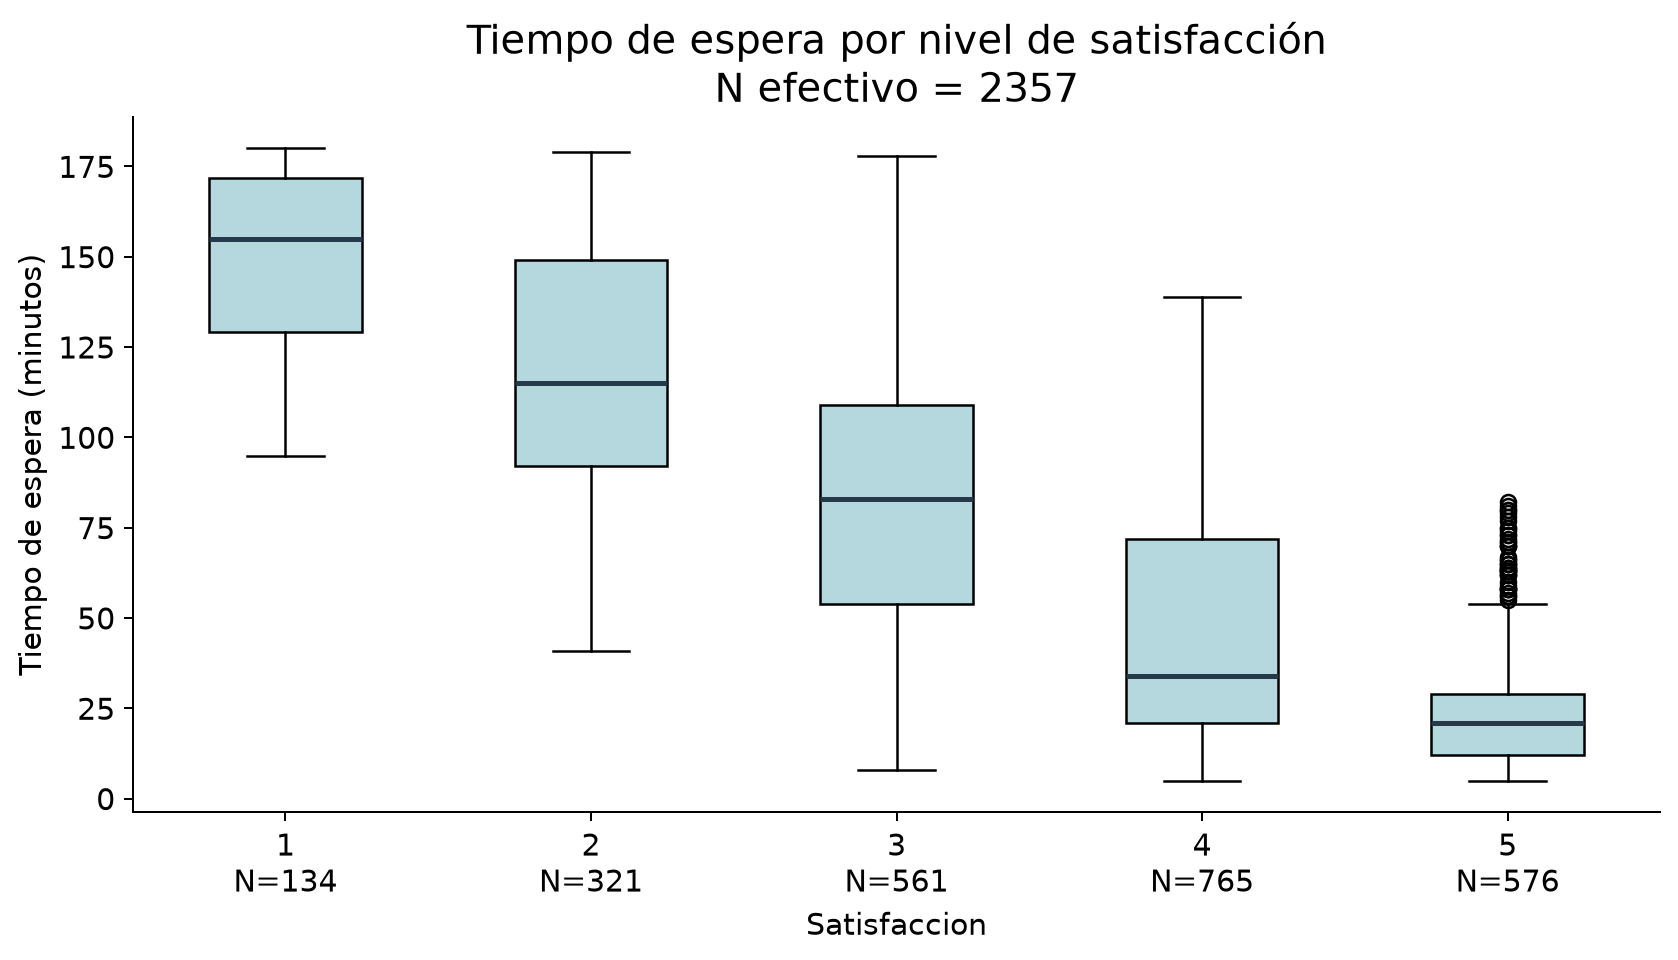

## 8. Acceso a medicación y satisfacción

N efectivo total: **2428**; excluidos por NA de satisfacción: **72**.

| Acceso | N disponible | NA  | Mediana | Moda | Nivel 1 % | Nivel 2 % | Nivel 3 % | Nivel 4 % | Nivel 5 % |
| ------ | -----------: | --: | ------: | ---- | --------: | --------: | --------: | --------: | --------: |
| Sí     |         1640 |  55 |   4.000 | 4    |     0.610 |     6.159 |    18.232 |    39.695 |    35.305 |
| No     |          788 |  17 |   3.000 | 3    |    16.371 |    28.807 |    35.152 |    18.147 |     1.523 |

**Visualización y justificación:** Barras agrupadas por nivel 1–5 conservan el orden ordinal y comparan porcentajes con denominadores específicos para Sí y No; no convierten satisfacción en continua.

![satisfaccion_por_acceso.png](../outputs/figuras/relaciones/satisfaccion_por_acceso.png)

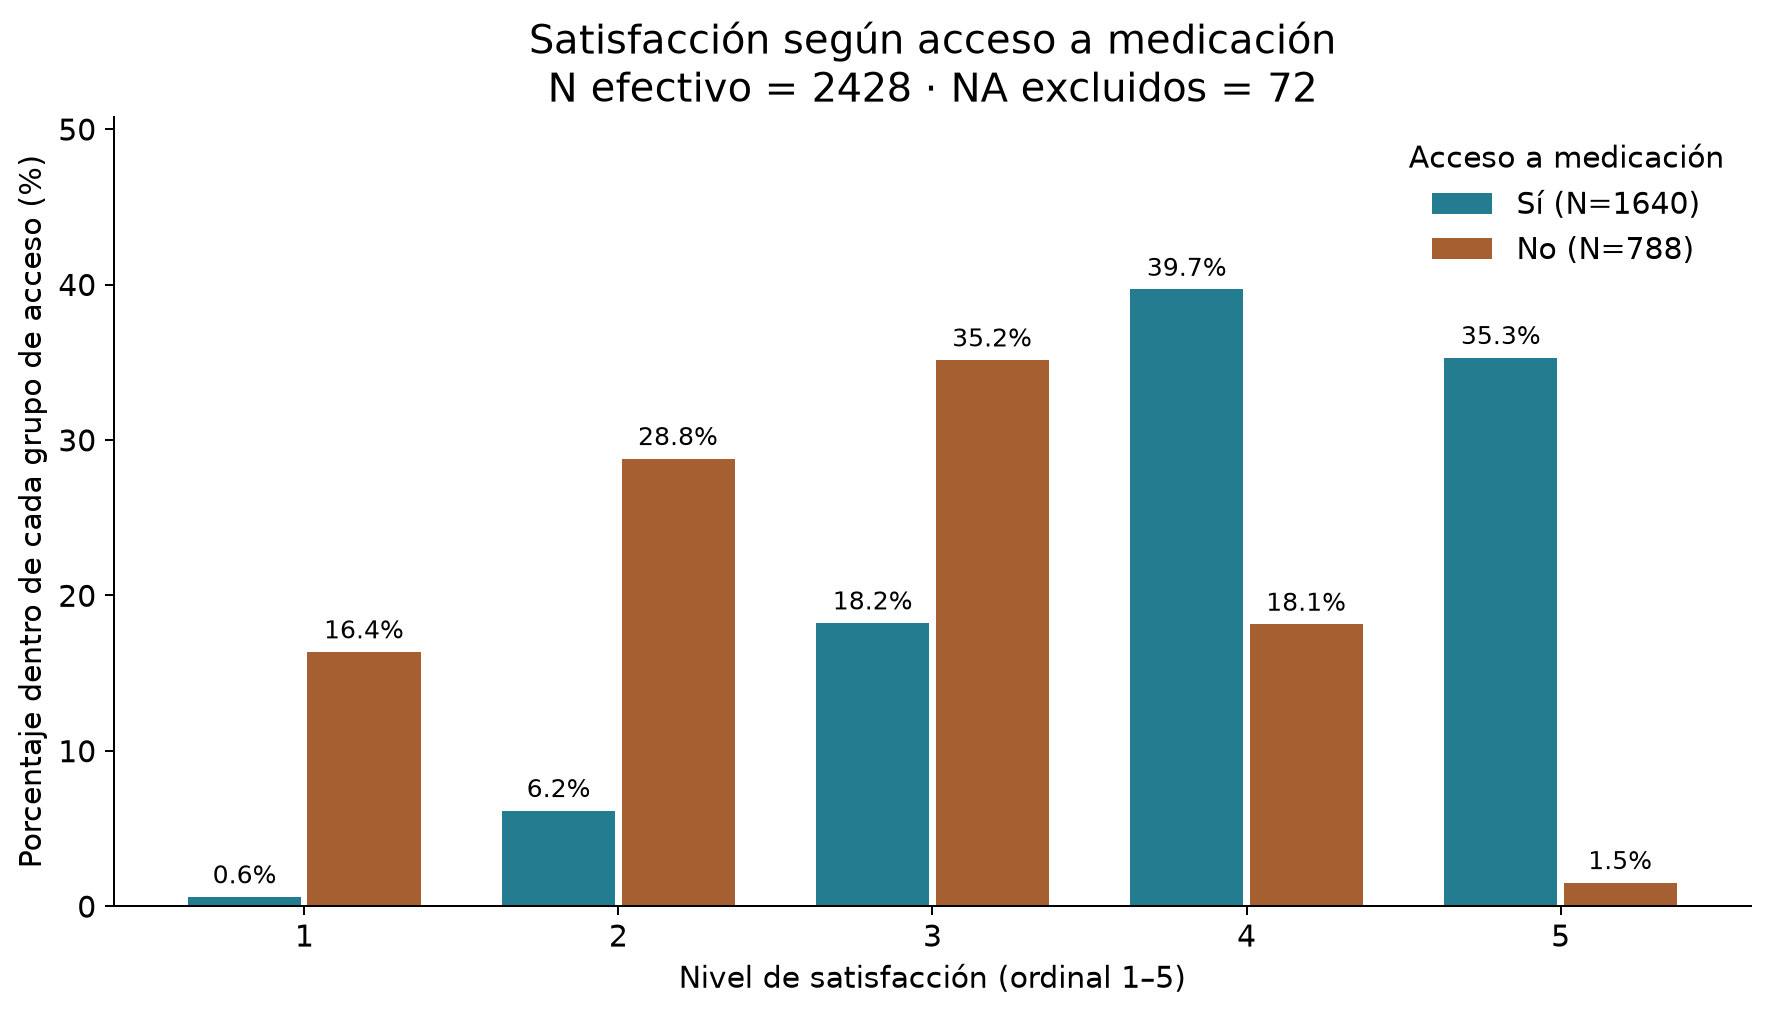

Con acceso: mediana 4, moda 4, N=1640; sin acceso: mediana 3, moda 3, N=788. La comparación es descriptiva. No se agrega una prueba: la distribución por niveles, mediana y moda responden la pregunta solicitada sin aumentar la familia de contrastes.

In [5]:
emit("## 7. Tiempo de espera y satisfacción")
pair=complete(["Tiempo_Espera_min","Satisfaccion"])
assert len(pair)==2357
emit(f"N efectivo: **{len(pair)}**; filas excluidas por NA en cualquiera de las dos variables: **{len(df)-len(pair)}**. "
     "Hay 74 NA en espera y 72 en satisfacción, con 3 coincidentes: 74 + 72 − 3 = 143 exclusiones. No se imputan valores.")
rho,p=stats.spearmanr(pair.Tiempo_Espera_min,pair.Satisfaccion,alternative="two-sided",nan_policy="raise")
# Comprobación independiente del coeficiente con rangos medios centrados.
x=stats.rankdata(pair.Tiempo_Espera_min); y=stats.rankdata(pair.Satisfaccion)
x=x-x.mean(); y=y-y.mean()
manual_rho=np.dot(x,y)/np.sqrt(np.dot(x,x)*np.dot(y,y))
assert np.isclose(rho,manual_rho)
t=rho*np.sqrt((len(pair)-2)/(1-rho*rho))
manual_p=2*stats.t.sf(abs(t),df=len(pair)-2)
assert np.isclose(p,manual_p,rtol=1e-10,atol=0)
emit(f"**Spearman bilateral:** ρ={rho:.4f}, p {pf(p)}, N={len(pair)}. "
     "Dirección negativa: los rangos de espera mayores tienden a acompañar niveles de satisfacción menores. "
     f"La magnitud absoluta |ρ|={abs(rho):.4f} indica una relación monotónica negativa marcada, sin equivaler a porcentaje de varianza explicada. "
     "Hay evidencia estadística al nivel nominal 0.05; no implica causalidad ni ajuste por acceso o cobertura. "
     "Se usa la aproximación asintótica del p-value con N>500 y rangos medios ante empates; no se utiliza Pearson como análisis principal. "
     "[Método e interpretación: SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).")
rows=[]
for level in [1,2,3,4,5]:
    s=pair.loc[pair.Satisfaccion.eq(level),"Tiempo_Espera_min"]
    rows.append([level,len(s),s.mean(),s.median(),s.quantile(.25),s.quantile(.75)])
emit(table(["Satisfacción","N","Media espera min","Mediana min","Q1 min","Q3 min"],rows,numeric=(0,1,2,3,4,5)))
box(pair,"Satisfaccion","Tiempo_Espera_min",[1,2,3,4,5],"Tiempo de espera por nivel de satisfacción","Tiempo de espera (minutos)","espera_por_satisfaccion.png")
summary.append(["Espera–satisfacción",len(pair),"Spearman bilateral",f"ρ={rho:.4f}",pf(p),f"ρ={rho:.4f}","Asociación monotónica negativa marcada."])
findings.append((f"ρ={rho:.4f}, p {pf(p)}, N={len(pair)}, 143 exclusiones por NA.","Se observa una asociación monotónica negativa marcada entre espera y satisfacción ordinal.","No es causal ni mide una relación ajustada; faltantes y empates limitan la interpretación inferencial."))
emit("## 8. Acceso a medicación y satisfacción")
sat=complete(["Acceso_Medicacion","Satisfaccion"])
sat_counts=pd.crosstab(sat.Acceso_Medicacion,sat.Satisfaccion).reindex(index=["Sí","No"],columns=[1,2,3,4,5],fill_value=0)
sat_pct=sat_counts.div(sat_counts.sum(axis=1),axis=0)*100
assert np.allclose(sat_pct.sum(axis=1),100) and sat_counts.to_numpy().sum()==len(sat)
sat_rows=[]
for access in ["Sí","No"]:
    s=sat.loc[sat.Acceso_Medicacion.eq(access),"Satisfaccion"]
    total=int(df.Acceso_Medicacion.eq(access).sum())
    sat_rows.append([access,len(s),total-len(s),s.median(),", ".join(str(int(v)) for v in s.mode()),*sat_pct.loc[access].tolist()])
emit(f"N efectivo total: **{len(sat)}**; excluidos por NA de satisfacción: **{len(df)-len(sat)}**.\n\n"+
     table(["Acceso","N disponible","NA","Mediana","Moda","Nivel 1 %","Nivel 2 %","Nivel 3 %","Nivel 4 %","Nivel 5 %"],sat_rows,numeric=(1,2,3,5,6,7,8,9)))
fig,ax=plt.subplots(figsize=(10,5.8))
positions=np.arange(5)
for offset,access,color in [(-.19,"Sí","#247C91"),(.19,"No","#A65F30")]:
    values=sat_pct.loc[access].to_numpy()
    bars=ax.bar(positions+offset,values,width=.36,color=color,label=f"{access} (N={sat_counts.loc[access].sum()})")
    ax.bar_label(bars,labels=[f"{v:.1f}%" for v in values],fontsize=10,padding=3)
ax.set(xticks=positions,xticklabels=["1","2","3","4","5"],xlabel="Nivel de satisfacción (ordinal 1–5)",ylabel="Porcentaje dentro de cada grupo de acceso (%)",title=f"Satisfacción según acceso a medicación\nN efectivo = {len(sat)} · NA excluidos = 72",ylim=(0,float(sat_pct.to_numpy().max())*1.28))
ax.legend(title="Acceso a medicación",frameon=False)
figure(fig,ax,"satisfaccion_por_acceso.png","Barras agrupadas por nivel 1–5 conservan el orden ordinal y comparan porcentajes con denominadores específicos para Sí y No; no convierten satisfacción en continua.")
sat_observation=f"Con acceso: mediana {sat_rows[0][3]:.0f}, moda {sat_rows[0][4]}, N={sat_rows[0][1]}; sin acceso: mediana {sat_rows[1][3]:.0f}, moda {sat_rows[1][4]}, N={sat_rows[1][1]}."
emit(sat_observation+" La comparación es descriptiva. No se agrega una prueba: la distribución por niveles, mediana y moda responden la pregunta solicitada sin aumentar la familia de contrastes.")
summary.append(["Medicación–satisfacción",len(sat),"No aplicada (descripción ordinal suficiente)",sat_observation,"No aplicada","No aplicada; porcentajes, medianas y modas","Comparación descriptiva; no se afirma significación."])
findings.append((sat_observation+f" Se excluyeron {len(df)-len(sat)} NA.","La satisfacción disponible se concentra en niveles distintos según acceso.","No se realizó contraste adicional ni ajuste por espera; no se atribuyen causas."))


In [6]:
emit("## 9. Resumen estadístico de relaciones\n\n"+
     table(["Relación","N efectivo","Método estadístico","Resultado principal","p-value","Medida de efecto/asociación","Interpretación breve"],summary,numeric=(1,)))
emit("En Kruskal-Wallis no se añade un índice estandarizado: se informa magnitud descriptiva con medianas, IQR y distribuciones, evitando traducir H o p a porcentaje explicado. "
     "Las dos secciones descriptivas indican No aplicada porque no plantean un contraste adicional. V y ρ cuantifican magnitud en sus análisis respectivos; no son medidas intercambiables.")
emit("## 10. Hallazgos principales")
for i,(result,interpretation,limitation) in enumerate(findings,1):
    emit(f"### Hallazgo {i}\n\n**RESULTADO:** {result}\n\n**INTERPRETACIÓN:** {interpretation}\n\n**LIMITACIÓN:** {limitation}")
emit("## 11. Limitaciones\n\n"
     "Los datos son ficticios y las relaciones fueron incorporadas intencionalmente según el caso de uso; los resultados no validan hechos sobre la población real. "
     "La independencia se supone, no se demuestra con IDs únicos. No se documenta un diseño muestral. "
     "Los análisis son exploratorios y los cinco p-values no están ajustados por multiplicidad; no se formulan conclusiones confirmatorias conjuntas. "
     "Los p-values no son probabilidades de que la hipótesis sea verdadera ni medidas de tamaño del efecto.\n\n"
     "El mecanismo de los NA es desconocido: cada resultado se limita a sus casos disponibles y puede tener selección no evaluada. "
     "Kruskal-Wallis detecta diferencias globales de rangos y puede responder a cambios de forma o dispersión, no exclusivamente a medianas. "
     "Spearman es monotónico, trata empates mediante rangos medios y usa un p-value asintótico. "
     "Chi-cuadrado se sustenta en los controles de frecuencias esperadas y en el supuesto de independencia. "
     "V no tiene dirección y sus umbrales de magnitud no son universales. "
     "Los análisis marginales no controlan otras variables; el heatmap no estima interacción ni efectos independientes. "
     "No se realizan afirmaciones causales ni recomendaciones finales.")
emit("## 12. Preguntas para la etapa de vulnerabilidad\n\n"
     "- ¿Qué dimensión de vulnerabilidad acordará el equipo y con qué fundamento, dado que no existe una etiqueta directa?\n"
     "- ¿Cómo distinguirá el equipo una dificultad observada de acceso o atención de una definición operacional de vulnerabilidad?\n"
     "- ¿Qué papel tendrán la disponibilidad de datos y el tamaño de cada combinación en una evaluación posterior?\n\n"
     "Estas preguntas quedan abiertas. No se define una regla, no se clasifica a pacientes ni se crean variables nuevas.")
pd.testing.assert_frame_equal(df,snapshot,check_exact=True)
assert len(figures)==7 and all(p.exists() and p.stat().st_size>1000 for p in figures)
assert len(findings)==7 and len(summary)==7
assert [len(a),len(b),c["n"],e["n"],len(joint),len(pair),len(sat)]==[2500,2426,2500,2500,2500,2357,2428]
for path,digest in hashes.items():
    assert hashlib.sha256(path.read_bytes()).hexdigest()==digest
emit("**Control final:** N efectivos y porcentajes reconciliados; frecuencias esperadas verificadas; χ², V y Spearman contrastados con fórmulas independientes; "
     "p-values de Kruskal-Wallis contrastados con la cola χ²₂. Se preservaron satisfacción ordinal, NA, datos y todos los archivos anteriores, verificando igualdad exacta del DataFrame y hashes SHA-256. "
     "Siete figuras no vacías y sin nuevas columnas en el dataset. Reproducción: notebooks/05_relaciones.ipynb.\n\n"
     f"SHA-256 del procesado intacto: {hashes[source]}.")
report="\n\n".join(parts)+"\n"
for link in re.findall(r"!\[[^\]]*\]\(([^)]+)\)",report):
    assert (root/"reports"/link).resolve().is_file()
(root/"reports/05_relaciones.md").write_text(report,encoding="utf-8")
print("Siete relaciones, cinco pruebas y siete figuras. Todas las validaciones aprobadas.")
print("RESUMEN:",summary)


## 9. Resumen estadístico de relaciones

| Relación                         | N efectivo | Método estadístico                           | Resultado principal                                                                                          | p-value     | Medida de efecto/asociación                              | Interpretación breve                                      |
| -------------------------------- | ---------: | -------------------------------------------- | ------------------------------------------------------------------------------------------------------------ | ----------- | -------------------------------------------------------- | --------------------------------------------------------- |
| Condición–frecuencia             |       2500 | Kruskal-Wallis                               | H=2042.640                                                                                                   | < 0.001     | No aplicada (estandarizada); medianas 1 / 4 / 13         | Diferencias globales de rangos; dispersión desigual.      |
| Cobertura–espera                 |       2426 | Kruskal-Wallis                               | H=1684.378                                                                                                   | < 0.001     | No aplicada (estandarizada); medianas 18 / 71 / 105 min  | Diferencias globales; no solo medias.                     |
| Cobertura–medicación             |       2500 | Chi-cuadrado                                 | χ²=255.798; gl=2                                                                                             | < 0.001     | V=0.3199                                                 | Asociación nominal; magnitud separada del p-value.        |
| Condición–medicación             |       2500 | Chi-cuadrado                                 | χ²=27.170; gl=2                                                                                              | < 0.001     | V=0.1042                                                 | Asociación nominal; magnitud separada del p-value.        |
| Cobertura + condición–medicación |       2500 | No aplicada (objetivo descriptivo)           | Mayor acceso observado: Privada / Aguda, 240/269 (89.22%); menor: Sin cobertura / Crónica, 118/281 (41.99%). | No aplicada | No aplicada (sin contraste); porcentajes por combinación | Nueve perfiles; no mide efectos ajustados ni interacción. |
| Espera–satisfacción              |       2357 | Spearman bilateral                           | ρ=-0.7402                                                                                                    | < 0.001     | ρ=-0.7402                                                | Asociación monotónica negativa marcada.                   |
| Medicación–satisfacción          |       2428 | No aplicada (descripción ordinal suficiente) | Con acceso: mediana 4, moda 4, N=1640; sin acceso: mediana 3, moda 3, N=788.                                 | No aplicada | No aplicada; porcentajes, medianas y modas               | Comparación descriptiva; no se afirma significación.      |

En Kruskal-Wallis no se añade un índice estandarizado: se informa magnitud descriptiva con medianas, IQR y distribuciones, evitando traducir H o p a porcentaje explicado. Las dos secciones descriptivas indican No aplicada porque no plantean un contraste adicional. V y ρ cuantifican magnitud en sus análisis respectivos; no son medidas intercambiables.

## 10. Hallazgos principales

### Hallazgo 1

**RESULTADO:** Medianas 1, 4 y 13 consultas para Saludable, Aguda y Crónica; H=2042.640, p < 0.001, N=2500.

**INTERPRETACIÓN:** Se observan diferencias globales de rangos y separación descriptiva de las distribuciones.

**LIMITACIÓN:** Sin post-hoc no se afirma significación de cada par; no es un efecto causal ni una prueba exclusiva de medianas.

### Hallazgo 2

**RESULTADO:** Medianas 18, 71 y 105 min; H=1684.378, p < 0.001, N=2426, 74 NA excluidos.

**INTERPRETACIÓN:** Las distribuciones de espera difieren entre coberturas en ubicación y dispersión.

**LIMITACIÓN:** El contraste global no prueba causalidad; las formas distintas impiden interpretarlo solo como prueba de medianas.

...

### Hallazgo 7

**RESULTADO:** Con acceso: mediana 4, moda 4, N=1640; sin acceso: mediana 3, moda 3, N=788. Se excluyeron 72 NA.

**INTERPRETACIÓN:** La satisfacción disponible se concentra en niveles distintos según acceso.

**LIMITACIÓN:** No se realizó contraste adicional ni ajuste por espera; no se atribuyen causas.

## 11. Limitaciones

Los datos son ficticios y las relaciones fueron incorporadas intencionalmente según el caso de uso; los resultados no validan hechos sobre la población real. La independencia se supone, no se demuestra con IDs únicos. No se documenta un diseño muestral. Los análisis son exploratorios y los cinco p-values no están ajustados por multiplicidad; no se formulan conclusiones confirmatorias conjuntas. Los p-values no son probabilidades de que la hipótesis sea verdadera ni medidas de tamaño del efecto.

El mecanismo de los NA es desconocido: cada resultado se limita a sus casos disponibles y puede tener selección no evaluada. Kruskal-Wallis detecta diferencias globales de rangos y puede responder a cambios de forma o dispersión, no exclusivamente a medianas. Spearman es monotónico, trata empates mediante rangos medios y usa un p-value asintótico. Chi-cuadrado se sustenta en los controles de frecuencias esperadas y en el supuesto de independencia. V no tiene dirección y sus umbrales de magnitud no son universales. Los análisis marginales no controlan otras variables; el heatmap no estima interacción ni efectos independientes. No se realizan afirmaciones causales ni recomendaciones finales.

## 12. Preguntas para la etapa de vulnerabilidad

- ¿Qué dimensión de vulnerabilidad acordará el equipo y con qué fundamento, dado que no existe una etiqueta directa?
- ¿Cómo distinguirá el equipo una dificultad observada de acceso o atención de una definición operacional de vulnerabilidad?
- ¿Qué papel tendrán la disponibilidad de datos y el tamaño de cada combinación en una evaluación posterior?

Estas preguntas quedan abiertas. No se define una regla, no se clasifica a pacientes ni se crean variables nuevas.

**Control final:** N efectivos y porcentajes reconciliados; frecuencias esperadas verificadas; χ², V y Spearman contrastados con fórmulas independientes; p-values de Kruskal-Wallis contrastados con la cola χ²₂. Se preservaron satisfacción ordinal, NA, datos y todos los archivos anteriores, verificando igualdad exacta del DataFrame y hashes SHA-256. Siete figuras no vacías y sin nuevas columnas en el dataset. Reproducción: notebooks/05_relaciones.ipynb.

SHA-256 del procesado intacto: 6707074a0d805b2fce33f461c10c9335adcb5ab302d960bc0e963db868b983bd.

Siete relaciones, cinco pruebas y siete figuras. Todas las validaciones aprobadas.
RESUMEN: [['Condición–frecuencia', 2500, 'Kruskal-Wallis', 'H=2042.640', '< 0.001', 'No aplicada (estandarizada); medianas 1 / 4 / 13', 'Diferencias globales de rangos; dispersión desigual.'], ['Cobertura–espera', 2426, 'Kruskal-Wallis', 'H=1684.378', '< 0.001', 'No aplicada (estandarizada); medianas 18 / 71 / 105 min', 'Diferencias globales; no solo medias.'], ['Cobertura–medicación', 2500, 'Chi-cuadrado', 'χ²=255.798; gl=2', '< 0.001', 'V=0.3199', 'Asociación nominal; magnitud separada del p-value.'], ['Condición–medicación', 2500, 'Chi-cuadrado', 'χ²=27.170; gl=2', '< 0.001', 'V=0.1042', 'Asociación nominal; magnitud separada del p-value.'], ['Cobertura + condición–medicación', 2500, 'No aplicada (objetivo descriptivo)', 'Mayor acceso observado: Privada / Aguda, 240/269 (89.22%); menor: Sin cobertura / Crónica, 118/281 (41.99%).', 'No aplicada', 'No aplicada (sin contraste); porcentajes por combinació